<a href="https://colab.research.google.com/github/Jashwanth248/ai-hw-Spring-2026-nn/blob/main/7_1_Attack_MNIST_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install torch torchvision matplotlib

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


Load MNIST Dataset

In [5]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.93MB/s]


Train samples: 60000
Test samples: 10000


Create CNN Model

In [6]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)

        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        x = F.max_pool2d(x, 2)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

model = CNN().to(device)

print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


Define Optimizer and Loss

In [7]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

criterion = nn.CrossEntropyLoss()

Train the Model

In [8]:
epochs = 3

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}")
    print("Loss:", running_loss / len(train_loader))

Epoch 1/3
Loss: 0.15158179642529343
Epoch 2/3
Loss: 0.04408893459734679
Epoch 3/3
Loss: 0.02698524888095221


Test Clean Accuracy

In [9]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

clean_accuracy = 100 * correct / total

print("Clean Accuracy:", clean_accuracy)

Clean Accuracy: 98.91


Implement FGSM Attack

In [10]:
def fgsm_attack(image, epsilon, data_grad):

    sign_data_grad = data_grad.sign()

    perturbed_image = image + epsilon * sign_data_grad

    perturbed_image = torch.clamp(perturbed_image, 0, 1)

    return perturbed_image

Test FGSM Attack

In [11]:
epsilon = 0.25

correct = 0
total = 0

adv_examples = []

for images, labels in test_loader:

    images = images.to(device)
    labels = labels.to(device)

    images.requires_grad = True

    outputs = model(images)

    _, init_pred = torch.max(outputs.data, 1)

    if init_pred.item() != labels.item():
        continue

    loss = criterion(outputs, labels)

    model.zero_grad()

    loss.backward()

    data_grad = images.grad.data

    perturbed_data = fgsm_attack(images, epsilon, data_grad)

    outputs = model(perturbed_data)

    _, final_pred = torch.max(outputs.data, 1)

    total += 1

    if final_pred.item() == labels.item():
        correct += 1

    else:
        if len(adv_examples) < 5:
            adv_ex = perturbed_data.squeeze().detach().cpu().numpy()
            adv_examples.append((init_pred.item(),
                                 final_pred.item(),
                                 adv_ex))

final_accuracy = correct / total

asr = 1 - final_accuracy

print("FGSM Accuracy:", final_accuracy * 100)
print("FGSM Attack Success Rate:", asr * 100)

FGSM Accuracy: 13.729653220099081
FGSM Attack Success Rate: 86.27034677990092


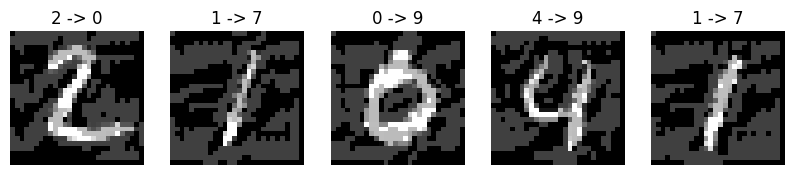

In [12]:
plt.figure(figsize=(10,5))

for i in range(len(adv_examples)):

    orig, adv, ex = adv_examples[i]

    plt.subplot(1, len(adv_examples), i+1)

    plt.imshow(ex, cmap="gray")

    plt.title(f"{orig} -> {adv}")

    plt.axis("off")

plt.show()

PGD Attack

In [13]:
def pgd_attack(model,
               images,
               labels,
               eps=0.3,
               alpha=0.01,
               iters=40):

    ori_images = images.clone()

    for i in range(iters):

        images.requires_grad = True

        outputs = model(images)

        loss = criterion(outputs, labels)

        model.zero_grad()

        loss.backward()

        adv_images = images + alpha * images.grad.sign()

        eta = torch.clamp(
            adv_images - ori_images,
            min=-eps,
            max=eps
        )

        images = torch.clamp(
            ori_images + eta,
            0,
            1
        ).detach()

    return images

TEST PGD Attack

In [14]:
correct = 0
total = 0

for images, labels in test_loader:

    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    _, pred = torch.max(outputs.data, 1)

    if pred.item() != labels.item():
        continue

    adv_images = pgd_attack(
        model,
        images,
        labels
    )

    outputs = model(adv_images)

    _, final_pred = torch.max(outputs.data, 1)

    total += 1

    if final_pred.item() == labels.item():
        correct += 1

pgd_accuracy = correct / total

pgd_asr = 1 - pgd_accuracy

print("PGD Accuracy:", pgd_accuracy * 100)
print("PGD ASR:", pgd_asr * 100)

PGD Accuracy: 0.0
PGD ASR: 100.0


Momentum I-FGSM

In [15]:
def mifgsm_attack(model,
                   images,
                   labels,
                   eps=0.3,
                   alpha=0.01,
                   iters=40,
                   decay=1.0):

    momentum = torch.zeros_like(images).to(device)

    ori_images = images.clone()

    for i in range(iters):

        images.requires_grad = True

        outputs = model(images)

        loss = criterion(outputs, labels)

        model.zero_grad()

        loss.backward()

        grad = images.grad.data

        grad_norm = grad / torch.mean(
            torch.abs(grad),
            dim=(1,2,3),
            keepdim=True
        )

        momentum = decay * momentum + grad_norm

        adv_images = images + alpha * momentum.sign()

        eta = torch.clamp(
            adv_images - ori_images,
            min=-eps,
            max=eps
        )

        images = torch.clamp(
            ori_images + eta,
            0,
            1
        ).detach()

    return images

MI-FGSM

In [16]:
correct = 0
total = 0

for images, labels in test_loader:

    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    _, pred = torch.max(outputs.data, 1)

    if pred.item() != labels.item():
        continue

    adv_images = mifgsm_attack(
        model,
        images,
        labels
    )

    outputs = model(adv_images)

    _, final_pred = torch.max(outputs.data, 1)

    total += 1

    if final_pred.item() == labels.item():
        correct += 1

mifgsm_accuracy = correct / total

mifgsm_asr = 1 - mifgsm_accuracy

print("MI-FGSM Accuracy:", mifgsm_accuracy * 100)
print("MI-FGSM ASR:", mifgsm_asr * 100)

MI-FGSM Accuracy: 0.060661207158022444
MI-FGSM ASR: 99.93933879284198


In [17]:
torch.save(model.state_dict(), "mnist_cnn.pth")

print("Model saved!")

Model saved!
